# Ali Abdullah Ahmad
## CWID-20031246
## Multi-Class Classification


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import string
import re
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

1. Data preparation (10 points)
    1) Data preprocessing (5 points): Please use the same data processing steps as you did in
    HW1. Please make sure to process the class labels based on the binary/multi-class
    classification task that you will be working on in HW2.
    2) Data split: Please use the same data split as you did in HW1.
    2
    3) Data statistics (5 points): Since you are using the same data split as in HW1, most of the
    data statistics will not be changed except for the number of reviews of each class in
    training/development/testing since the class labels are changed in HW2. Please provide the
    number of reviews of each class in training/development/testing for the classification task
    in HW2.

In [35]:
df = pd.read_csv('./amazon_reviews.csv')
df.head()

,overall,reviewText
0,4,No issues.
1,5,"Purchased this for my device, it worked as adv..."
2,4,it works as expected. I should have sprung for...
3,5,This think has worked out great.Had a diff. br...
4,5,"Bought it with Retail Packaging, arrived legit..."


In [36]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
punct = string.punctuation
numbers = string.digits

def clean_text(text):
    if pd.isnull(text):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = text.translate(str.maketrans('', '', punct + numbers))
    # Remove stopwords and return tokens 
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

df['reviewText'] = df['reviewText'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
df['overall'].value_counts()

overall
5    3922
4     527
1     244
3     142
2      80
Name: count, dtype: int64

### 1 -> Highly Negative Review
### 2 -> Negative Review
### 3 -> Neutral Review
### 4 -> Positive Review
### 5 -> Highly Positive Review

In [38]:
X = df['reviewText']
y = df['overall']

In [39]:
X_train , X_temp , y_train , y_temp = train_test_split( X , y , 
                                                       test_size= 0.2 , # 20% goes to val+test
                                                       stratify= y,     # keeps class distribution same across splits
                                                       random_state=42) # reproducibility

In [40]:
X_val , X_test , y_val , y_test = train_test_split(X_temp,y_temp,
                                                   test_size=0.5, #50% of 20 -> 10% each in validation and test
                                                   stratify=y_temp,
                                                   random_state=42)

In [41]:
print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))

print("Label distribution in Train:\n", y_train.value_counts(normalize=True))
print("Label distribution in Val:\n", y_val.value_counts(normalize=True))
print("Label distribution in Test:\n", y_test.value_counts(normalize=True))

Train size: 3932
Val size: 491
Test size: 492
Label distribution in Train:
 overall
5    0.798067
4    0.107070
1    0.049593
3    0.028993
2    0.016277
Name: proportion, dtype: float64
Label distribution in Val:
 overall
5    0.798371
4    0.107943
1    0.048880
3    0.028513
2    0.016293
Name: proportion, dtype: float64
Label distribution in Test:
 overall
5    0.796748
4    0.107724
1    0.050813
3    0.028455
2    0.016260
Name: proportion, dtype: float64


In [42]:
token_stats = pd.DataFrame({
    'Set': ['Train', 'Validation', 'Test'],
    'Min Tokens': [X_train.apply(len).min(), X_val.apply(len).min(), X_test.apply(len).min()],
    'Avg Tokens': [X_train.apply(len).mean(), X_val.apply(len).mean(), X_test.apply(len).mean()],
    'Max Tokens': [X_train.apply(len).max(), X_val.apply(len).max(), X_test.apply(len).max()]
})
token_stats

,Set,Min Tokens,Avg Tokens,Max Tokens
0,Train,0,25.457782,781
1,Validation,1,24.712831,424
2,Test,1,25.463415,183


2. Sentiment Analysis with RNN (40 points)
Please write the code to perform the sentiment analysis task you formulated in question 1.
During the implementation, you will need to follow the requirements listed below.
    1) You can select to implement 2-layer LSTM or GRU (you can directly call packages in
    Pytorch).
    2) Please use SGD during optimization.
    3) Please initialize the word embeddings randomly and learn them during the model training.
    4) You can decide other parameters.

In [43]:
# Create a function to get corpus words
def get_vocab(corpus):
    """Determine a list of distinct words for the corpus"""
    distinct_words = []
    for i in range(len(corpus)):
        for word in corpus[i]:
            if word not in distinct_words:
                distinct_words.append(word)
    corpus_words = sorted(distinct_words)
    return corpus_words

# Create a function to get dictionary of the distinct words
def dict_words(corpus):
    """Build a dictionary of distinct words from the corpus"""
    dict_words = {}
    for word in corpus:
        if word not in dict_words:
            dict_words[word] = len(dict_words)
    return dict_words

# Combine all reviews from train, val, and test sets into one corpus
combined_corpus = list(X_train) + list(X_val) + list(X_test)

# Call the functions to get corpus words and dictionary of the words
corpus_words = get_vocab(combined_corpus)
dict_words = dict_words(corpus_words)


In [44]:
# Tokenizer for converting words to numerical form
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(X_train)  # fit only on training data

# Convert each dataset to sequences
X_train = word_tokenizer.texts_to_sequences(X_train)
X_val = word_tokenizer.texts_to_sequences(X_val)
X_test = word_tokenizer.texts_to_sequences(X_test)

# Padding all reviews to fixed length 200
max_length = 200
X_train = pad_sequences(X_train, padding='post', maxlen=max_length, truncating='post')
X_val = pad_sequences(X_val, padding='post', maxlen=max_length, truncating='post')
X_test = pad_sequences(X_test, padding='post', maxlen=max_length, truncating='post')

In [ ]:
# Cell 1: build + train (no evaluation)

def rnn_train(X_train, y_train, X_val, y_val, corpus_words,
                  max_length=200, hidden_size=20, learning_rate=0.001,
                  num_epochs=5, rnn_type="lstm"):
    """
    Build and train a 2-layer RNN (LSTM/GRU) with random trainable embeddings and SGD.
    Keras + Tokenizer + pad_sequences inputs.
    """

    # Hyperparameters 
    input_size = len(corpus_words) + 1   # vocab size (+1)
    output_classes = 5                   # 5-class sentiment (1..5)
    num_layers = 2                       # exactly 2 recurrent layers

    # Map labels 1..5 -> 0..4 for sparse_categorical_crossentropy
    y_train_adj = np.asarray(y_train) - 1
    y_val_adj   = np.asarray(y_val) - 1

    # Define the model
    model = keras.Sequential()

    # Random, trainable embeddings (requirement 3)
    model.add(keras.layers.Embedding(input_dim=input_size,
                                     output_dim=hidden_size,
                                     input_length=max_length))

    # Add LSTM layers
    model.add(keras.layers.Bidirectional(
        keras.layers.LSTM(hidden_size, return_sequences=True)))
    model.add(keras.layers.Bidirectional(
        keras.layers.LSTM(hidden_size)))

    model.add(keras.layers.Dense(output_classes, activation='softmax'))

    # SGD optimizer (requirement 2)
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)

    # Compile
    model.compile(optimizer=optimizer,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train 
    history = model.fit(
        X_train, y_train_adj,
        epochs=num_epochs,
        validation_data=(X_val, y_val_adj),
        verbose=1
    )

    return model, history


In [ ]:
import seaborn as sns
def rnn_eval(model, history, X_test, y_test):
    """
    Evaluate a trained model: accuracy, classification report, confusion matrix,
    plus training/validation curves.
    """


    # Convert labels 1..5 -> 0..4 to compare with model outputs
    y_test_adj = np.asarray(y_test) - 1

    # Enhanced accuracy and loss plots
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], marker='o', linestyle='-', color='royalblue', linewidth=2)
    plt.plot(history.history['val_accuracy'], marker='s', linestyle='--', color='tomato', linewidth=2)
    plt.title('Model Accuracy', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.legend(['Train', 'Validation'], loc='lower right', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], marker='o', linestyle='-', color='purple', linewidth=2)
    plt.plot(history.history['val_loss'], marker='s', linestyle='--', color='orange', linewidth=2)
    plt.title('Model Loss', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(['Train', 'Validation'], loc='upper right', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred_0based = np.argmax(y_pred_probs, axis=1)

    # Metrics (report back in original 1..5 scale for readability)
    y_pred = y_pred_0based + 1
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=3)
    cm = confusion_matrix(y_test, y_pred)

    print("accuracy:", acc)
    print("\nclassification report:\n", report)
    print("\nconfusion matrix:\n", cm)

    # Visually appealing confusion matrix heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False, 
                xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5], linewidths=0.5,
                annot_kws={'fontsize':13, 'fontweight':'bold'})
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.tight_layout()
    plt.show()

    return acc, report, cm


Epoch 1/15


c:\Users\abdul\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - accuracy: 0.7805 - loss: 1.4901 - val_accuracy: 0.7984 - val_loss: 1.3776
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.7981 - loss: 1.2816 - val_accuracy: 0.7984 - val_loss: 1.1896
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - accuracy: 0.7981 - loss: 1.1145 - val_accuracy: 0.7984 - val_loss: 1.0438
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - accuracy: 0.7981 - loss: 0.9905 - val_accuracy: 0.7984 - val_loss: 0.9410
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - accuracy: 0.7981 - loss: 0.9063 - val_accuracy: 0.7984 - val_loss: 0.8735
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 0.7981 - loss: 0.8519 - val_accuracy: 0.7984 - val_loss: 0.8305
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - accuracy: 0.7981 - loss: 0.8172 - val_accuracy: 0.7984 - val_loss: 0.8029
Epoch 8/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - accuracy: 0.7981 - loss: 0.7950 - val

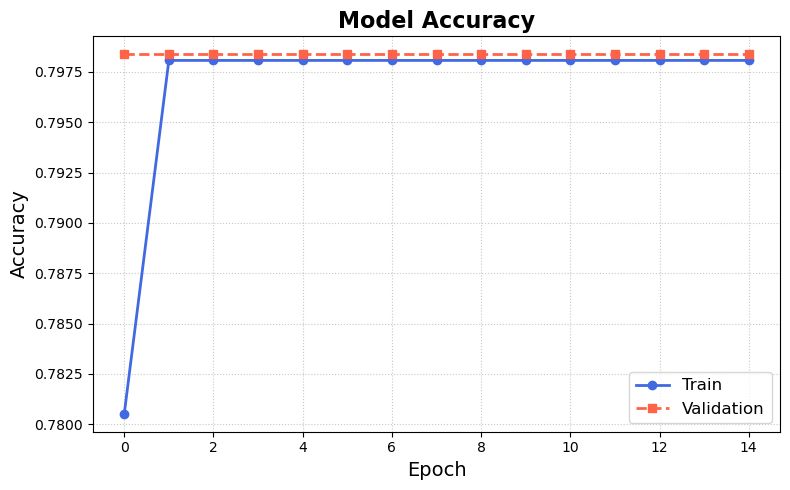

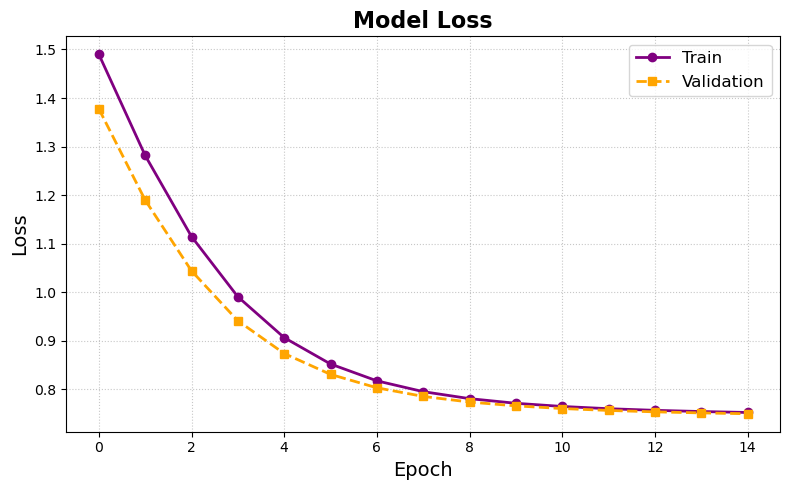

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step
accuracy: 0.7967479674796748

classification report:
               precision    recall  f1-score   support

           1      0.000     0.000     0.000        25
           2      0.000     0.000     0.000         8
           3      0.000     0.000     0.000        14
           4      0.000     0.000     0.000        53
           5      0.797     1.000     0.887       392

    accuracy                          0.797       492
   macro avg      0.159     0.200     0.177       492
weighted avg      0.635     0.797     0.707       492


confusion matrix:
 [[  0   0   0   0  25]
 [  0   0   0   0   8]
 [  0   0   0   0  14]
 [  0   0   0   0  53]
 [  0   0   0   0 392]]


c:\Users\abdul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\abdul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\abdul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


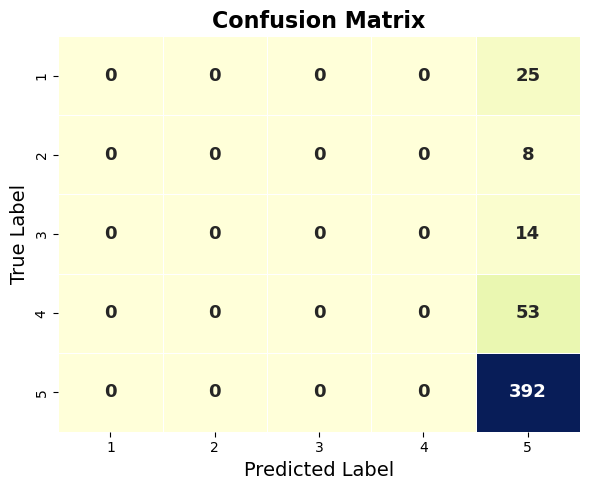

In [47]:
# Train (Cell 1)
model, history = rnn_train(X_train, y_train, X_val, y_val, corpus_words,
                               max_length=200, hidden_size=20,
                               learning_rate=0.001, num_epochs=15,
                               rnn_type="lstm")  

# Evaluate (Cell 2)
accuracy, class_report, conf_matrix = rnn_eval(model, history, X_test, y_test)


3. Sentiment Analysis with CNN (40 points)
Please write the code to perform the sentiment analysis task you formulated in question 1.
During the implementation, you will need to follow the requirements listed below. Feel free to
use any packages and libraries.
    1) Please use mini-batch gradient descent method during optimization with batch size 20.
    2) Please initialize the word embeddings with the pre-trained glove embeddings you used
    in HW1 and update them during the model training.
    3) You can decide other parameters.

In [48]:
# Download the embedding model
def load_embedding_model():
    """Load GloVe Vectors"""
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin

wv_from_bin = load_embedding_model()

def get_matrix_of_vectors(wv_from_bin, required_words, dict_words):
    """
    Build an embedding matrix aligned with dict_words indices.
    required_words: list of distinct words (e.g., corpus_words)
    dict_words: dict mapping word -> index
    """
    dim = wv_from_bin.vector_size  # use model’s actual dim, not a hardcode
    vocab_size = len(dict_words)
    embedding_matrix = np.zeros((vocab_size, dim), dtype=np.float32)

    default_vector = np.zeros(dim, dtype=np.float32)  # keep zeros for OOV

    # Fill by index so rows align with your word->index mapping
    hits = 0
    for word, idx in dict_words.items():
        if word in wv_from_bin:
            embedding_matrix[idx] = wv_from_bin.get_vector(word)
            hits += 1
        else:
            embedding_matrix[idx] = default_vector

    print(f"Done. Filled {hits}/{vocab_size} words with GloVe vectors.")
    return embedding_matrix

# Build matrix (aligned to your dict_words indices)
embedding_matrix = get_matrix_of_vectors(wv_from_bin, corpus_words, dict_words)
embedding_matrix


Loaded vocab size 400000
Done. Filled 6494/9697 words with GloVe vectors.


array([[ 0.22586 ,  0.055649,  0.28368 , ..., -0.28357 ,  0.36353 ,
        -0.8737  ],
       [ 0.23273 , -0.048693,  0.76813 , ..., -0.55684 , -0.44096 ,
         0.203   ],
       [-0.075412,  0.34158 , -0.66105 , ...,  0.14579 , -0.57616 ,
        -0.022035],
       ...,
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [-0.35548 ,  0.22649 , -0.37089 , ..., -0.062321,  0.19923 ,
        -0.15657 ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ]], dtype=float32)

In [49]:
# Define the CNN model
def cnn_model(max_length, input_size, output_classes, learning_rate, embedding_matrix):
    """A function to define the CNN model"""

    # Infer embedding dims from the provided matrix (avoids shape mismatch)
    vocab_size, emb_dim = embedding_matrix.shape

    # Create the input layer
    input_layer = Input(shape=(max_length,))

    # Embedding layer initialized with GloVe weights 
    embedding_layer = Embedding(
        input_dim=vocab_size,          
        output_dim=emb_dim,           
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    )(input_layer)

    # Apply convolutional layers with different kernel sizes
    conv1 = Conv1D(filters=100, kernel_size=3, activation='relu')(embedding_layer)
    conv2 = Conv1D(filters=100, kernel_size=4, activation='relu')(embedding_layer)
    conv3 = Conv1D(filters=100, kernel_size=5, activation='relu')(embedding_layer)

    # Global max-pooling for each branch
    pool1 = GlobalMaxPooling1D()(conv1)
    pool2 = GlobalMaxPooling1D()(conv2)
    pool3 = GlobalMaxPooling1D()(conv3)

    # Concatenate pooled features
    merged = keras.layers.concatenate([pool1, pool2, pool3], axis=-1)

    # Output layer
    output_layer = Dense(output_classes, activation='softmax')(merged)

    model = keras.models.Model(inputs=input_layer, outputs=output_layer)
    return model


In [50]:
def cnn(X_train, y_train, X_val, y_val, X_test, y_test,
            max_length, input_size, output_classes, learning_rate,
            num_epochs, batch_size, embedding_matrix):
    """A function to implement the CNN model"""

    # Build model
    model = cnn_model(max_length, input_size, output_classes, learning_rate, embedding_matrix)

    # Optimizer: SGD (as required)
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9, nesterov=True)

    # If labels are 1..5, map to 0..4 for sparse_categorical_crossentropy
    y_train_adj = np.asarray(y_train) - 1
    y_val_adj   = np.asarray(y_val) - 1
    y_test_adj  = np.asarray(y_test) - 1  # used only for sklearn metrics after predict

    # Compile
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train
    history = model.fit(X_train, y_train_adj, batch_size=batch_size, epochs=num_epochs,
                        validation_data=(X_val, y_val_adj), verbose=1)

    # Evaluate (Keras)
    loss, accuracy = model.evaluate(X_test, y_test_adj, verbose=0)
    print(f"Testing loss: {loss}")
    print(f"Testing accuracy: {accuracy}")

    sns.set(style="whitegrid", font_scale=1.2)
    plt.figure(figsize=(9, 6))
    plt.plot(history.history['accuracy'], marker='o', linestyle='-', linewidth=2, label='Train', color='#0072B2')
    plt.plot(history.history['val_accuracy'], marker='s', linestyle='--', linewidth=2, label='Validation', color='#D55E00')
    plt.title('Model Accuracy', fontsize=18, fontweight='bold', color='#333333', pad=15)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.legend(loc='lower right', fontsize=12, frameon=True)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, which='both', linestyle=':', linewidth=0.7)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 6))
    plt.plot(history.history['loss'], marker='o', linestyle='-', linewidth=2, label='Train', color='#009E73')
    plt.plot(history.history['val_loss'], marker='s', linestyle='--', linewidth=2, label='Validation', color='#CC79A7')
    plt.title('Model Loss', fontsize=18, fontweight='bold', color='#333333', pad=15)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(loc='upper right', fontsize=12, frameon=True)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, which='both', linestyle=':', linewidth=0.7)
    plt.tight_layout()
    plt.show()

    # Predict on the test set
    y_pred_probs = model.predict(X_test)
    y_pred_0based = np.argmax(y_pred_probs, axis=1)

    # Report in original 1..5 scale for readability
    y_pred = y_pred_0based + 1
    acc = accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    return acc, class_report, conf_matrix


c:\Users\abdul\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7859 - loss: 0.7770 - val_accuracy: 0.7984 - val_loss: 0.7144
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7976 - loss: 0.6848 - val_accuracy: 0.7984 - val_loss: 0.6929
Epoch 3/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7991 - loss: 0.6468 - val_accuracy: 0.7984 - val_loss: 0.6863
Epoch 4/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8009 - loss: 0.6134 - val_accuracy: 0.7984 - val_loss: 0.6845
Epoch 5/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8009 - loss: 0.5818 - val_accuracy: 0.7984 - val_loss: 0.6732
Epoch 6/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8039 - loss: 0.5486 - val_accuracy: 0.7943 - val_loss: 0.6701
Epoch 7/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8105 - loss: 0.5175 - val_accuracy: 0.7963 - val_loss: 0.6675
Epoch 8/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8169 - loss: 0.4864 - val_accu

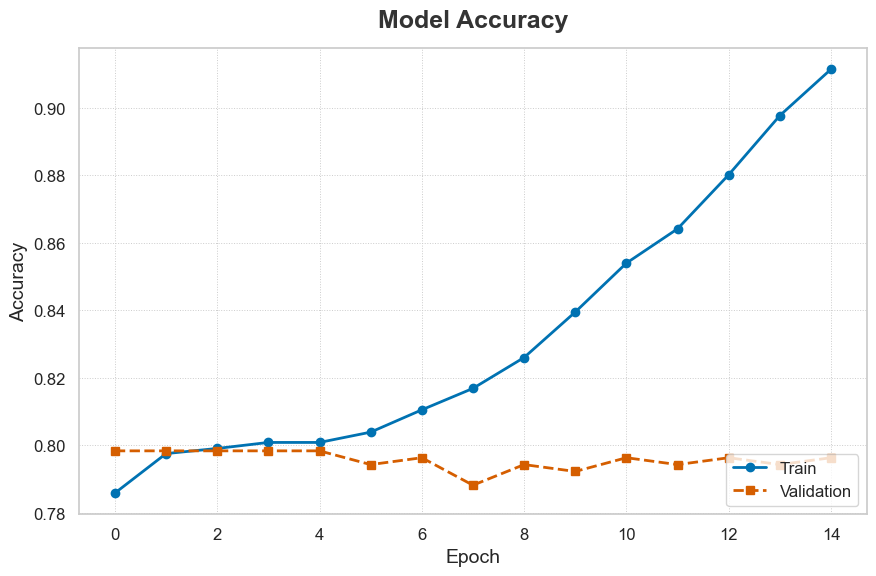

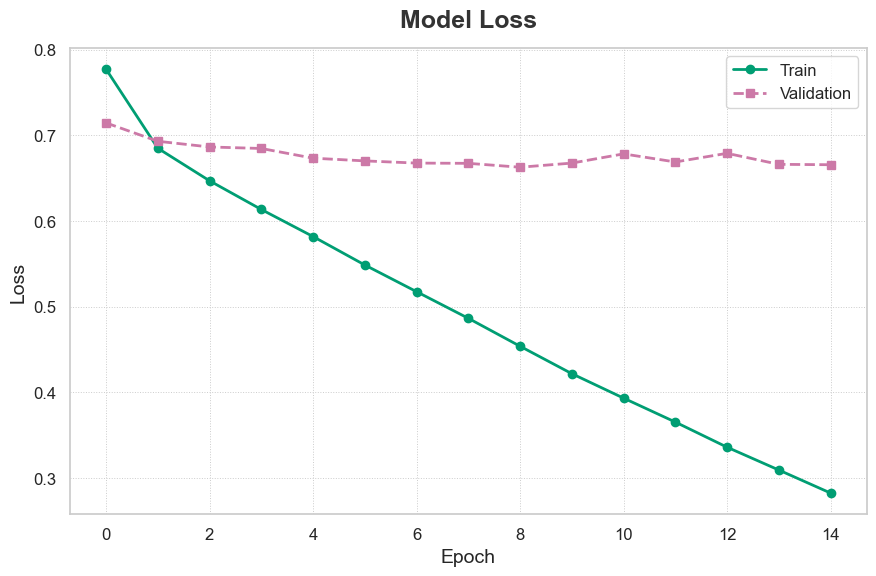

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
accuracy: 0.7926829268292683

classification report:
              precision    recall  f1-score   support

           1       0.36      0.16      0.22        25
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00        14
           4       0.17      0.04      0.06        53
           5       0.82      0.98      0.89       392

    accuracy                           0.79       492
   macro avg       0.27      0.24      0.24       492
weighted avg       0.69      0.79      0.73       492


confusion matrix:
[[  4   0   0   2  19]
 [  2   0   0   1   5]
 [  2   0   0   1  11]
 [  1   0   0   2  50]
 [  2   0   0   6 384]]


c:\Users\abdul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\abdul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\abdul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
# Define hyperparameters for CNN
max_length   = 200
input_size   = len(corpus_words)  # kept as your variable, not used by Embedding when weights provided
output_classes = 5                # FIXED (5 classes)
learning_rate = 0.001
num_epochs   = 15
batch_size   = 20


accuracy, class_report, conf_matrix = cnn(
    X_train, y_train, X_val, y_val, X_test, y_test,
    max_length, input_size, output_classes, learning_rate,
    num_epochs, batch_size, embedding_matrix
)

print("accuracy:", accuracy)
print("\nclassification report:")
print(class_report)
print("\nconfusion matrix:")
print(conf_matrix)


4. Evaluation (10 points):
Train the model on the training set, select the best model based on the validation set, and
evaluate your model on the testing set.
    1) Evaluate the model performance using metrics for classification, such as accuracy,
    precision, recall, F1-score, and AUC. Report your results for both methods. You can use
    existing pacakges in sklearn. (4 points)
    2) Have a brief discussion to compare the performance of the two models. It should be noted
    that there is no fixed answer for the results. You will need to report the exact results
    returned in your experiments. The discussions should only be based on your own
    experimental settings and returned results. (3 points)
    3) Are there any differences between the results you obtained in HW1 and HW2? Which
    model performs best? Can you please provide some discussions about your findings? It
    would be great to think about and discuss the underlying reasons for the outperformance
    of the best model. (3 points)

### ``1)Evaluation of rnn and cnn have been done after their model implementation respectively``

### ``2) Overall Accuracy``
| Model                       | Validation Accuracy | Test Accuracy |
| --------------------------- | ------------------- | ------------- |
| **RNN (2-layer BiLSTM)**    |  79.8 %            | **79.7 %**    |
| **CNN (1D-CNN with GloVe)** |  79.6 %            | **79.3 %**    |

Both models achieve almost identical overall accuracy (around 79 %), suggesting they are learning roughly the same signal from the data.

| Class             | RNN Recall | CNN Recall | Comment                                     |
| ----------------- | ---------- | ---------- | ------------------------------------------- |
| 1–4 (low ratings) | 0 %        | 4–16 %     | Both models struggle because of data imbalance. |
| 5 (high rating)   | 100 %      | 98 %       | Dominant class drives overall accuracy.     |

    a)The dataset is highly imbalanced (most reviews labeled 5), so both models tend to predict class 5.
    b)CNN shows slightly better recall for lower-rating classes than the RNN, though still poor.

### 3)

1. In **HW1**, I implemented **Logistic Regression** and a **Neural Network** for **binary sentiment classification**, where reviews with scores from **1 to 3** were labeled as *negative* and those above 3 as *positive*. These models were relatively simple yet effective.

2. The **Logistic Regression model** achieved an **accuracy of 0.9289**, with a **precision of 0.94** and **recall of 0.98** for positive reviews. Its confusion matrix showed that it correctly classified most positive reviews (**436 out of 445**), though it struggled more with negative ones (**21 out of 47**).

   Similarly, the **Neural Network model** reached an **accuracy of 0.9309**, with a **precision of 0.93** and **recall of 0.99** for positive reviews. Despite a slightly lower recall for negative reviews (**0.34**), the overall performance remained strong, as reflected by the **weighted F1-score of 0.92**.

3. These high accuracies can be attributed to the **binary classification setup**, where distinguishing between only two classes (*positive vs. negative*) is comparatively simpler. Additionally, positive reviews were the majority, which likely helped the models achieve higher performance.

4. In contrast, **HW2** required implementing more complex architectures like **RNN** and **CNN** for **multi-class sentiment classification** (five classes). This task is inherently more challenging, demanding a larger and more balanced dataset for effective training. In my dataset, reviews with a score of **5** were dominant, creating a **class imbalance** that led the models to favor predicting the highest rating. As a result, both the RNN and CNN underperformed compared to the simpler models from HW1.

5. In conclusion, for this dataset and task size, the **simpler models in HW1 (Logistic Regression and Neural Network)** performed better, achieving over **93% accuracy**. However, with a larger, more balanced dataset, the **advanced sequence models in HW2 (RNN and CNN)** would likely outperform the simpler baselines by better capturing **contextual and sequential patterns** in the text.


![Image](image.png)